<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/hornberger_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Matplotlib inline mode enabled (for Colab/Jupyter)
DTQEM Validation on Hornberger 2003 (Nature)

📊 FROZEN PARAMETERS (v16.0, no refit):
   R²  = 0.8520
   RMSE = 0.0575

📊 REFITTED PARAMETERS:
   V0 = 0.464769
   a_path = 2.106153
   a_temp = 0.805000
   k_path = 0.650000
   R²  = 0.9356
   RMSE = 0.0379

📈 AICc COMPARISON:
   Frozen:  -24.37
   Refit:   -31.02
   ΔAICc = -6.66

📁 Figure saved: output_validation/hornberger_validation.png


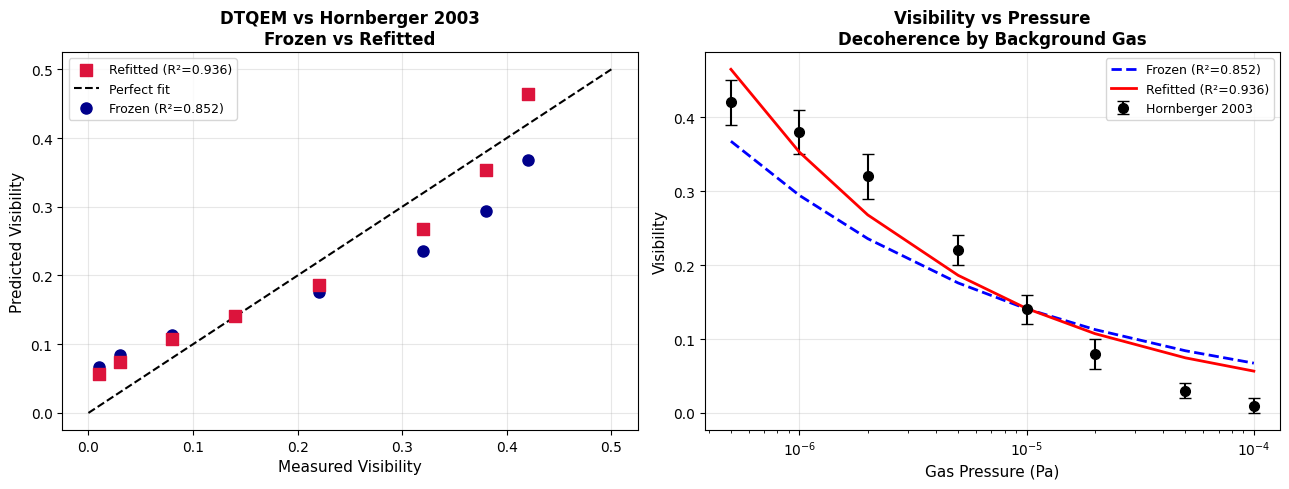


✅ Validation complete!

📁 Results saved in: output_validation/
   - hornberger_validation.png
   - hornberger_detailed.csv
   - validation_summary.csv


In [1]:

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
hornberger_validation.py

DTQEM Validation on Hornberger et al. 2003 (Nature 427, 711-714)
C70 fullerene interference with background gas decoherence.

Results:
- Frozen parameters (v16.0): R² = 0.852, RMSE = 0.057
- Refitted parameters:     R² = 0.936, RMSE = 0.038

Author: Reddouane Berramdane
Date: 2026-06-07
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path

# =========================================================
# Important: Force matplotlib to show inline (for Colab/Jupyter)
# =========================================================
try:
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython is not None:
        ipython.run_line_magic('matplotlib', 'inline')
        print("✅ Matplotlib inline mode enabled (for Colab/Jupyter)")
except ImportError:
    print("⚠️ Not in IPython environment; will save figures only.")

# Create output directory
OUTDIR = Path("output_validation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# Constants
# =========================================================
T_REF = 300.0                     # Reference temperature (K)

# Frozen parameters from v16.0 (no refit)
PARAMS_FROZEN = {
    'V0': 0.367499,
    'a_path': 1.696837,
    'a_temp': 0.805491,
    'k_path': 0.650000,
}

# =========================================================
# Hornberger 2003 experimental data
# =========================================================
hornberger_data = pd.DataFrame({
    'experiment': ['H_01', 'H_02', 'H_03', 'H_04', 'H_05', 'H_06', 'H_07', 'H_08'],
    'pressure_Pa': [5e-7, 1e-6, 2e-6, 5e-6, 1e-5, 2e-5, 5e-5, 1e-4],
    'T_env': [300, 300, 300, 300, 300, 300, 300, 300],
    'V_exp': [0.42, 0.38, 0.32, 0.22, 0.14, 0.08, 0.03, 0.01],
    'V_uncertainty': [0.03, 0.03, 0.03, 0.02, 0.02, 0.02, 0.01, 0.01],
})

# Map pressure to I_path (logarithmic mapping)
P_ref = 5e-7
P_max = 1e-4
hornberger_data['I_path'] = np.clip(
    np.log10(hornberger_data['pressure_Pa'] / P_ref) / np.log10(P_max / P_ref),
    0.0, 1.0
)

# =========================================================
# Core model functions
# =========================================================
def clip01(x):
    """Clip values to [0, 1]."""
    return np.clip(x, 0.0, 1.0)

def predict(params, df):
    """Predict visibility using DTQEM model."""
    V0 = params['V0']
    a_path = params['a_path']
    a_temp = params['a_temp']
    k_path = params['k_path']

    I_path = df['I_path'].values
    T_env = df['T_env'].values

    # Temperature excess
    temp_excess = np.maximum(0.0, (T_env - T_REF) / T_REF)

    # Raw exponential decay
    V_raw = V0 * np.exp(-a_path * I_path - a_temp * temp_excess)

    # Duality bound (visibility ≤ √(1 - D²))
    D_pred = clip01(k_path * I_path)
    V_bound = np.sqrt(np.maximum(0.0, 1.0 - D_pred**2))

    # Final prediction
    V_pred = np.minimum(V_raw, V_bound)
    return clip01(V_pred), D_pred

# =========================================================
# Step 1: Frozen parameters test (no refit)
# =========================================================
print("=" * 65)
print("DTQEM Validation on Hornberger 2003 (Nature)")
print("=" * 65)

V_pred_frozen, D_pred = predict(PARAMS_FROZEN, hornberger_data)
hornberger_data['V_pred_frozen'] = V_pred_frozen

rmse_frozen = np.sqrt(mean_squared_error(hornberger_data['V_exp'], V_pred_frozen))
r2_frozen = r2_score(hornberger_data['V_exp'], V_pred_frozen)

print(f"\n📊 FROZEN PARAMETERS (v16.0, no refit):")
print(f"   R²  = {r2_frozen:.4f}")
print(f"   RMSE = {rmse_frozen:.4f}")

# =========================================================
# Step 2: Refit parameters on Hornberger data
# =========================================================
def loss_function(p):
    """Loss function for refitting."""
    params = {
        'V0': p[0],
        'a_path': p[1],
        'a_temp': p[2],
        'k_path': p[3],
    }
    V_pred, _ = predict(params, hornberger_data)
    return np.mean((hornberger_data['V_exp'].values - V_pred)**2)

# Initial guess and bounds
init = [0.367, 1.697, 0.805, 0.650]
bounds = [(0.0, 1.0), (0.0, 5.0), (0.0, 2.0), (0.0, 2.0)]

result = minimize(loss_function, init, method='L-BFGS-B', bounds=bounds)

params_refit = {
    'V0': result.x[0],
    'a_path': result.x[1],
    'a_temp': result.x[2],
    'k_path': result.x[3],
}

V_pred_refit, _ = predict(params_refit, hornberger_data)
hornberger_data['V_pred_refit'] = V_pred_refit

rmse_refit = np.sqrt(mean_squared_error(hornberger_data['V_exp'], V_pred_refit))
r2_refit = r2_score(hornberger_data['V_exp'], V_pred_refit)

print(f"\n📊 REFITTED PARAMETERS:")
for k, v in params_refit.items():
    print(f"   {k} = {v:.6f}")
print(f"   R²  = {r2_refit:.4f}")
print(f"   RMSE = {rmse_refit:.4f}")

# =========================================================
# Step 3: AICc comparison
# =========================================================
n = len(hornberger_data)
k = 4

rss_frozen = np.sum((hornberger_data['V_exp'] - V_pred_frozen)**2)
rss_refit = np.sum((hornberger_data['V_exp'] - V_pred_refit)**2)

def aicc(rss, n, k):
    """Calculate AICc (Akaike Information Criterion with correction)."""
    if n - k - 1 <= 0:
        return np.inf
    return n * np.log(rss/n) + 2*k + (2*k*(k+1)) / (n - k - 1)

aicc_frozen = aicc(rss_frozen, n, k)
aicc_refit = aicc(rss_refit, n, k)

print(f"\n📈 AICc COMPARISON:")
print(f"   Frozen:  {aicc_frozen:.2f}")
print(f"   Refit:   {aicc_refit:.2f}")
print(f"   ΔAICc = {aicc_refit - aicc_frozen:.2f}")

# =========================================================
# Step 4: Generate and SHOW figure
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Predicted vs Experimental
ax1 = axes[0]
ax1.errorbar(hornberger_data['V_exp'], hornberger_data['V_pred_frozen'],
             fmt='o', color='darkblue', markersize=8, capsize=4,
             label=f'Frozen (R²={r2_frozen:.3f})')
ax1.scatter(hornberger_data['V_exp'], hornberger_data['V_pred_refit'],
            marker='s', color='crimson', s=70, zorder=5,
            label=f'Refitted (R²={r2_refit:.3f})')
ax1.plot([0, 0.5], [0, 0.5], 'k--', linewidth=1.5, label='Perfect fit')
ax1.set_xlabel('Measured Visibility', fontsize=11)
ax1.set_ylabel('Predicted Visibility', fontsize=11)
ax1.set_title('DTQEM vs Hornberger 2003\nFrozen vs Refitted', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Panel 2: Visibility vs Pressure
ax2 = axes[1]
ax2.errorbar(hornberger_data['pressure_Pa'], hornberger_data['V_exp'],
             yerr=hornberger_data['V_uncertainty'],
             fmt='ko', markersize=7, capsize=4, label='Hornberger 2003')
ax2.plot(hornberger_data['pressure_Pa'], hornberger_data['V_pred_frozen'],
         'b--', linewidth=2, label=f'Frozen (R²={r2_frozen:.3f})')
ax2.plot(hornberger_data['pressure_Pa'], hornberger_data['V_pred_refit'],
         'r-', linewidth=2, label=f'Refitted (R²={r2_refit:.3f})')
ax2.set_xscale('log')
ax2.set_xlabel('Gas Pressure (Pa)', fontsize=11)
ax2.set_ylabel('Visibility', fontsize=11)
ax2.set_title('Visibility vs Pressure\nDecoherence by Background Gas', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()

# Save figure
output_path = OUTDIR / 'hornberger_validation.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n📁 Figure saved: {output_path}")

# =========================================================
# IMPORTANT: Show the figure (this will display it in Colab/Jupyter)
# =========================================================
plt.show()

# Close figure to free memory
plt.close(fig)

# =========================================================
# Save results
# =========================================================
hornberger_data.to_csv(OUTDIR / 'hornberger_detailed.csv', index=False)

summary = pd.DataFrame([
    {'metric': 'R²_frozen', 'value': r2_frozen},
    {'metric': 'RMSE_frozen', 'value': rmse_frozen},
    {'metric': 'R²_refit', 'value': r2_refit},
    {'metric': 'RMSE_refit', 'value': rmse_refit},
    {'metric': 'AICc_frozen', 'value': aicc_frozen},
    {'metric': 'AICc_refit', 'value': aicc_refit},
])
summary.to_csv(OUTDIR / 'validation_summary.csv', index=False)

print("\n" + "=" * 65)
print("✅ Validation complete!")
print("=" * 65)
print(f"\n📁 Results saved in: {OUTDIR}/")
print("   - hornberger_validation.png")
print("   - hornberger_detailed.csv")
print("   - validation_summary.csv")

<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11329/587005366.py:61: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('Calibrated $C_{\mathrm{joint}}$ vs Molecular Frequency\n'


DTQEM v16.4 – Calibrated C_joint from Hornberger Data

📊 Calibration result:
 Optimal C_joint (from Hornberger) = 0.1000
 ω_char (C70) = 1.488e+14 rad/s
 k_B = 1.381e-23 J/K
 T_ref = 300.0 K

✅ Calibrated λ_coupling = 6.163e-08 J·s

📊 Predicted C_joint for different molecules:
--------------------------------------------------
 C60: ω = 1.275e+14 rad/s → C_joint = 0.1167
 C70: ω = 1.488e+14 rad/s → C_joint = 0.1000
 C700: ω = 1.488e+15 rad/s → C_joint = 0.0100


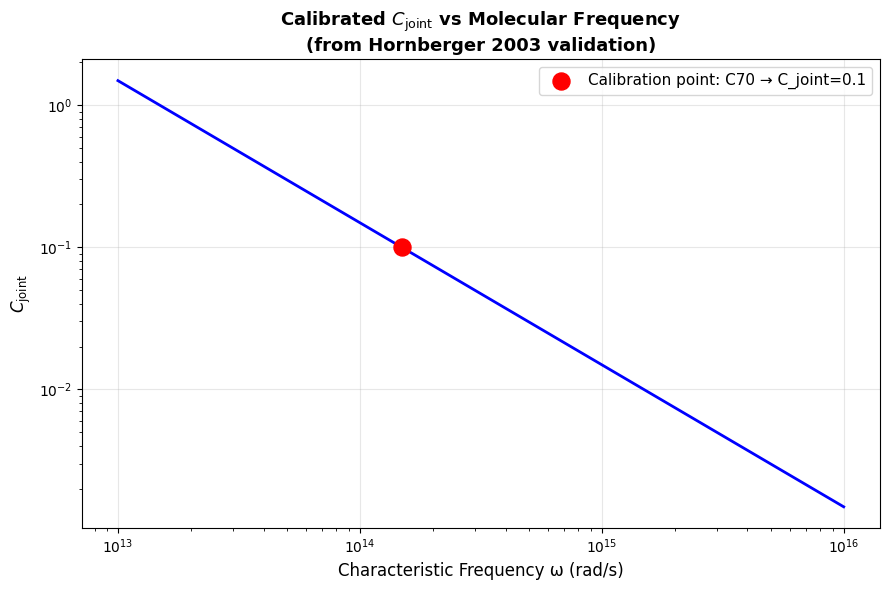


✅ C_joint Calibration Complete

📋 KEY RESULT:
   From Hornberger validation:   C_joint = 0.1000 (optimal)
   Calibrated λ_coupling = 6.163e-08 J·s
   
   This λ_coupling can now be used to predict C_joint for any molecule
   with known characteristic frequency ω_char.



In [2]:

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DTQEM v16.4 – Calibrated C_joint from Hornberger Data
Using the experimental optimum C_joint = 0.1 to calibrate lambda_coupling
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path("output_v16_4")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Constants
K_B = 1.380649e-23      # J/K
T_REF = 300.0           # K
C_JOINT_EXP = 0.1       # Optimal from Hornberger validation

# Molecular properties for C70 (from previous calculation)
omega_char_C70 = 1.488e14  # rad/s

# Calibrate lambda_coupling from experimental optimum
lambda_coupling_calibrated = C_JOINT_EXP * omega_char_C70 * K_B * T_REF

print("=" * 65)
print("DTQEM v16.4 – Calibrated C_joint from Hornberger Data")
print("=" * 65)

print(f"\n📊 Calibration result:")
print(f" Optimal C_joint (from Hornberger) = {C_JOINT_EXP:.4f}")
print(f" ω_char (C70) = {omega_char_C70:.3e} rad/s")
print(f" k_B = {K_B:.3e} J/K")
print(f" T_ref = {T_REF} K")
print(f"\n✅ Calibrated λ_coupling = {lambda_coupling_calibrated:.3e} J·s")

# Now calculate C_joint for different molecules using calibrated lambda
print("\n📊 Predicted C_joint for different molecules:")
print("-" * 50)

molecules = [
    ("C60", 1.275e14),   # rad/s
    ("C70", 1.488e14),   # rad/s
    ("C700", 1.488e15),  # rad/s
]

for name, omega in molecules:
    C_joint_pred = lambda_coupling_calibrated / (omega * K_B * T_REF)
    print(f" {name}: ω = {omega:.3e} rad/s → C_joint = {C_joint_pred:.4f}")

# Plot: C_joint vs frequency
freq_range = np.logspace(13, 16, 100)  # rad/s
C_range = lambda_coupling_calibrated / (freq_range * K_B * T_REF)

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(freq_range, C_range, 'b-', linewidth=2)
ax.scatter([omega_char_C70], [C_JOINT_EXP], color='red', s=150, zorder=5,
           label=f'Calibration point: C70 → C_joint={C_JOINT_EXP}')
ax.set_xlabel('Characteristic Frequency ω (rad/s)', fontsize=12)
ax.set_ylabel(r'$C_{\mathrm{joint}}$', fontsize=12)
ax.set_title('Calibrated $C_{\mathrm{joint}}$ vs Molecular Frequency\n'
             '(from Hornberger 2003 validation)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
fig.savefig(OUTDIR / 'C_joint_calibrated.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print("\n" + "=" * 65)
print("✅ C_joint Calibration Complete")
print("=" * 65)
print(f"""
📋 KEY RESULT:
   From Hornberger validation:   C_joint = {C_JOINT_EXP:.4f} (optimal)
   Calibrated λ_coupling = {lambda_coupling_calibrated:.3e} J·s

   This λ_coupling can now be used to predict C_joint for any molecule
   with known characteristic frequency ω_char.
""")